In [14]:
models.download_model('cellpose_sam')

AttributeError: module 'cellpose.models' has no attribute 'download_model'

In [1]:
import torch
from cellpose import models, utils
import numpy as np
import scipy as sc
import skimage as sk
import os
import czifile
import matplotlib.pyplot as plt
import pandas as pd

def check_gpu():
    if torch.cuda.is_available():
        num_gpus = torch.cuda.device_count()
        print(f"✅ CUDA is available! {num_gpus} GPU(s) detected.\n")
        
        for i in range(num_gpus):
            print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
    else:
        print("❌ CUDA is not available. Running on CPU.")

check_gpu()

✅ CUDA is available! 2 GPU(s) detected.

GPU 0: NVIDIA GeForce RTX 2070
GPU 1: NVIDIA GeForce RTX 2070


In [2]:
# IMAGE_PATH = r"Data\Sample1_GFP_only_no_BF_log_condition.czi"
IMAGE_PATH = r"Data\Sample2_BF_reference_cells.tif"
# IMAGE_PATH = r"Data\Sample2_GFP_chromatin_nuclei1.czi"
z_axis = 2 # 3
c_axis = None # 2
p_axis = None # 0
t_axis = None # 1

segmentation_channel = 1
measurement_channel = 0

OUTPUT_PATH = None

p, t = 0, 0

In [3]:
# Load images
root, ext = os.path.splitext(IMAGE_PATH)

# czi
if ext == '.czi':
    img = czifile.imread(IMAGE_PATH)

    # there is a weird axis in the last position in the czi file
    # were gonna remove it, but this might not be true to do for all czis of your file type
    idx = [slice(None)] * img.ndim
    idx[-1] = 0
    img = img[tuple(idx)]

    print(img.shape)


# tif
elif ext == '.tif':
    img = sk.io.imread(IMAGE_PATH)
    print(img.shape)

else:
    raise NotImplemented("path type not implemented")

(2204, 2744, 3)


In [4]:
# max project
if z_axis:
    maxProj = np.max(img, axis=z_axis) # keepdims=True, Easier way of doing this
    idx = [slice(None)] * maxProj.ndim
    idx.insert(z_axis, np.newaxis)
    maxProj = maxProj[tuple(idx)]
else:
    maxProj = img
maxProj.shape

(2204, 2744, 1)

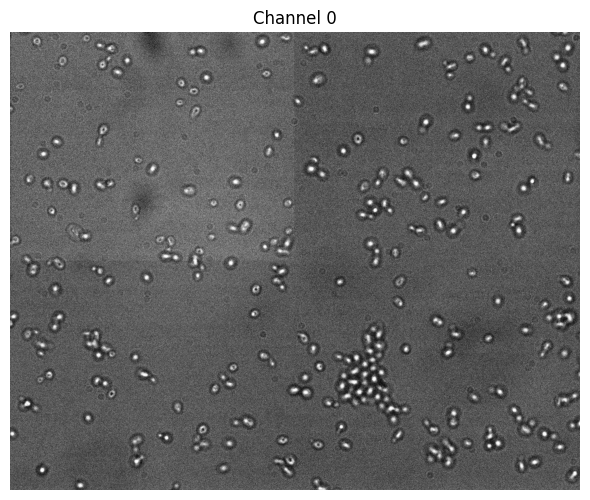

In [ ]:
# display each channel
if c_axis:
    num_channels = img.shape[c_axis]
else:
    num_channels = 1

fig, axes = plt.subplots(1, num_channels, figsize=(6 * num_channels, 6))
if num_channels == 1:
    axes = [axes]

for c in range(num_channels):
    idx = [slice(None)] * maxProj.ndim
    if p_axis:
        idx[p_axis] = p
    if t_axis:
        idx[t_axis] = t
    if c_axis:
        idx[c_axis] = c
    if z_axis:
        idx[z_axis] = 0
    channel_img = maxProj[tuple(idx)]
    axes[c].imshow(channel_img, cmap='gray')
    axes[c].set_title(f"Channel {c}")
    axes[c].axis('off')
    axes[c].set_aspect('equal')

plt.tight_layout()
plt.show()

pretrained model C:\Users\formanj\.cellpose\models\cpsam not found, using default model


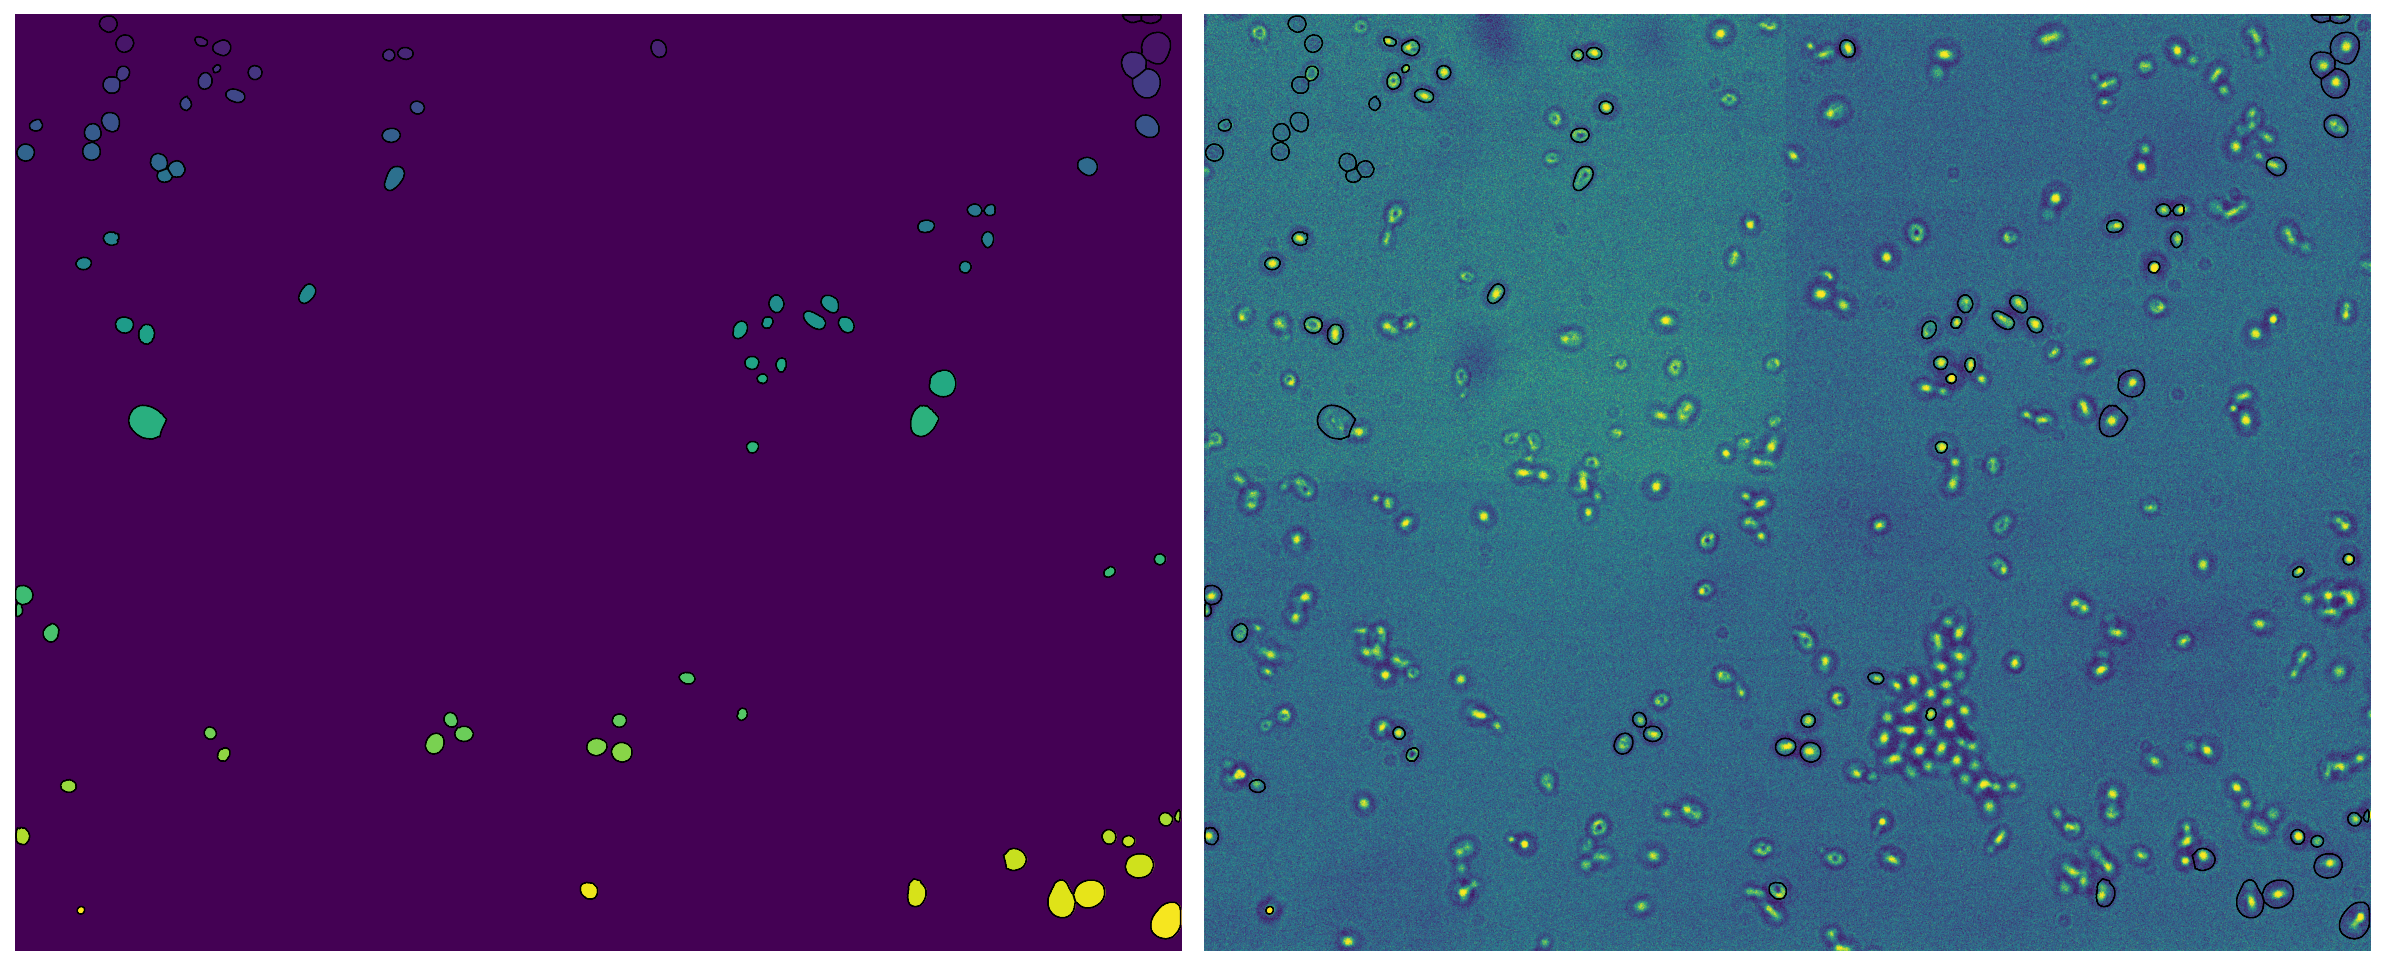

In [ ]:
# segment cells 
idx = [slice(None)] * maxProj.ndim
if p_axis:
    idx[p_axis] = p
if t_axis:
    idx[t_axis] = t
if z_axis:
    idx[z_axis] = 0
if c_axis:
    idx[c_axis] = segmentation_channel
idx = tuple(idx)

model = models.CellposeModel(gpu=True, pretrained_model='cpsam')
masks, flows, style = model.eval(maxProj[idx])

fig, axes = plt.subplots(1, 2, figsize=(16, 8), dpi=150)
outlines = utils.masks_to_outlines(masks)
axes[0].imshow(masks, cmap='viridis')
axes[0].contour(outlines, colors='black', linewidths=0.5)
axes[0].axis('off')
axes[1].imshow(maxProj[idx], cmap='viridis')
axes[1].contour(outlines, colors='black', linewidths=0.5)
axes[1].axis('off')
for ax in axes:
    ax.set_aspect('equal')
plt.tight_layout()
plt.show()

In [7]:
# Measure the yeast properties
if c_axis:
    num_channels = img.shape[c_axis]
else:
    num_channels = 1

# Extract one channel
idx = [slice(None)] * maxProj.ndim
if p_axis:
    idx[p_axis] = p
if t_axis:
    idx[t_axis] = t
if z_axis:
    idx[z_axis] = 0
if c_axis:
    idx[c_axis] = measurement_channel
idx = tuple(idx)
# channel_img = np.take(img, c, axis=c_axis) # also a cool trick
channel_img = img[idx]

props = sk.measure.regionprops_table(
    masks,
    intensity_image=channel_img,
    properties=[
        "label",
        "area",
        "centroid",
        "mean_intensity",
        "max_intensity",
        "min_intensity",
        "bbox"
    ]
)

df = pd.DataFrame(props)
df["channel"] = c

df

,label,area,centroid-0,centroid-1,mean_intensity,max_intensity,min_intensity,bbox-0,bbox-1,bbox-2,bbox-3,channel
0,1,842.0,9.593824,2672.176960,90.279097,255.0,0.0,0,2650,22,2697,0
1,2,681.0,8.631424,2629.114537,66.516887,221.0,0.0,1,2605,20,2650,0
2,3,1285.0,22.240467,219.326848,100.617121,249.0,0.0,4,198,43,241,0
3,4,4061.0,78.482147,2684.556267,87.201921,255.0,0.0,42,2650,117,2719,0
4,5,1365.0,68.356044,257.846886,100.168498,255.0,0.0,48,237,90,280,0
...,...,...,...,...,...,...,...,...,...,...,...,...
79,80,4314.0,2083.827075,2461.463839,83.767501,255.0,0.0,2036,2430,2126,2496,0
80,81,3835.0,2069.016428,2527.361669,82.494915,255.0,0.0,2037,2490,2103,2564,0
81,82,1316.0,2061.460486,1350.170973,132.947568,255.0,0.0,2042,1330,2083,1371,0
82,83,4832.0,2132.720406,2709.348717,85.021523,255.0,0.0,2089,2672,2176,2743,0


In [8]:
if OUTPUT_PATH:
    df.to_csv(OUTPUT_PATH)

In [11]:
models.MODELS_DIR

AttributeError: module 'cellpose.models' has no attribute 'MODELS_DIR'